In [1]:
import cudf
import cugraph
import numpy as np
import pandas as pd

In [2]:
import os
GRAPHML_FILE = "readability_optimization/input_graphs/price_10000nodes.graphml"
# convert the graphml to csv by running python csv2tsv.py -i price_10000nodes.graphml under the input_graph folder
CSV_FILE = "readability_optimization/input_graphs/fixed_price_10000nodes-edges.csv"
params = [] 
print(os. getcwd())

/scratch/maxzhang/GraphOptima


In [3]:
cudf_edgelist = cudf.read_csv(CSV_FILE,
                              names=["source", "target"],
                              dtype=["string", "string"],
                              sep='\t')
G = cugraph.Graph()
G.from_cudf_edgelist(cudf_edgelist, source='source', destination='target')

/opt/conda/lib/python3.11/site-packages/cugraph/structure/symmetrize.py:93: FutureWarning: Multi is deprecated and the removal of multi edges will no longer be supported from 'symmetrize'. Multi edges will be removed upon creation of graph instance.
  warnings.warn(


In [4]:
cudf_edgelist.head()

,source,target
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [5]:
position_dff = cugraph.force_atlas2(G, max_iter=1790, gravity=93436, scaling_ratio=2787)
fd = position_dff.to_pandas().sort_values(by=['vertex'])
gd = fd.drop(columns=['vertex'])
pos_list = gd.values.tolist()

In [6]:
print(position_dff.head())

            x           y vertex
0   74.980766 -257.175476   1274
1  124.000359 -539.343262    279
2 -222.380249   -4.785298   5812
3   77.536095   41.907082   4426
4 -398.692749  147.089355   5980


In [7]:
import graph_tool.all as gt
import pandas as pd
import os

def pos_df_to_graph(graphml, pos_df, resolution=500):
    # Load the graph
    g = gt.load_graph(graphml)

    # Create a vector<double> property map for positions
    pos = g.new_vertex_property("vector<double>")
    for _, row in pos_df.iterrows():
        vertex_index = int(row['vertex'])  # Use the vertex directly as an integer index
        pos[vertex_index] = [float(row['x']), float(row['y'])]  # Ensure x and y are floats
    
    # Assign the position property to the graph
    g.vertex_properties['pos'] = pos

    # Draw the graph using the positions
    gt.graph_draw(g, pos=pos, output_size=(resolution, resolution))
    


(ipykernel_launcher.py:82627): Gtk-WARNING **: 14:43:47.245: Locale not supported by C library.
	Using the fallback 'C' locale.


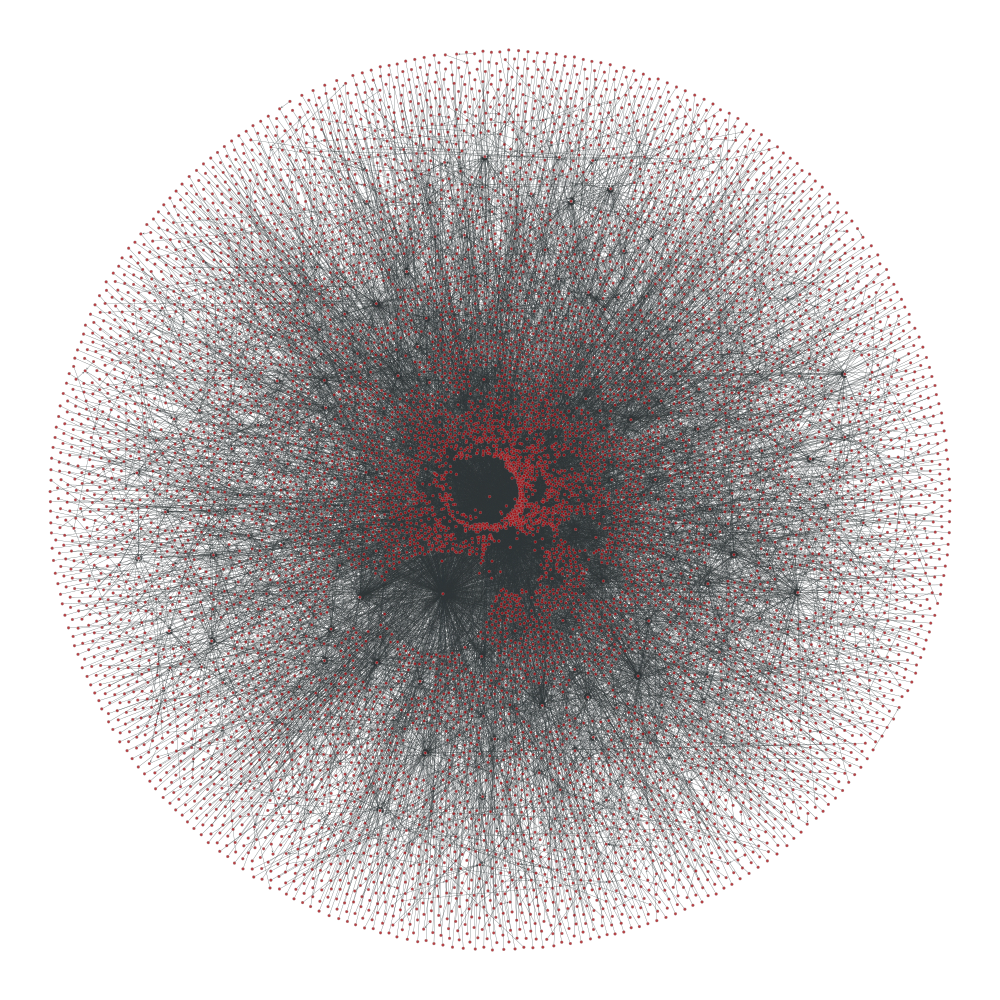

In [8]:
pos_df_to_graph(GRAPHML_FILE, position_dff.to_pandas())